# Zarrify EFAS long-run
***

**Date**: 09-03-2026<br>
**Author**: Chus Casado Rodríguez<br>

In [4]:
import xarray as xr
import zarr
from zarr.codecs import BloscCodec
from pathlib import Path
from tqdm.auto import tqdm

In [5]:
ds = xr.open_mfdataset(
    '~/Data/EFAS5/Iberia/meteo/pr/*202*.nc',
    chunks={'time': 365}
    ).astype('float32')

/tmp/ipykernel_1360/2169038725.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


In [6]:
da = ds['pr']

In [8]:
time_dim, lat_dim, lon_dim = da.dims

In [10]:
shards = (100, 50, 20)
step_time, lat_dim, lon_dim = shards

In [11]:
step_time

100

In [ ]:
time_dim

'time'

In [29]:
clean_attrs(da.attrs)

{'standard_name': 'precipitation_amount',
 'long_name': 'Daily Accumulated Precipitation',
 'cell_methods': 'time: sum',
 'units': 'mm',
 'valid_min': 0,
 'valid_max': 6000,
 'grid_mapping': 'wgs_1984',
 'esri_pe_string': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]]'}

In [30]:
clean_attrs(ds.attrs)

{'history': 'lisfloodutilities cutmaps 0.12.23 2025-03-31 16:15 \n Created Wed Jul  5 10:45:29 2023',
 'reference': 'A European daily high-resolution gridded meteorological data set for 1990 - 2022',
 'title': 'Lisflood meteo maps 1990-2023 for European setting Feb. 2023',
 'keywords': 'Lisflood, Europe',
 'source': 'Lisflood Europe meteo maps - pb2015',
 'institution': 'JRC E1',
 'comment': 'The timestamp marks the end of the aggregation interval for a given map. e.g.: A daily map with the timestamp of 1990-01-02 06:00 represents the data aggregated from 1990-01-01 06:00:01 to 1990-01-02 06:00:00',
 'conventions': 'CF-1.6',
 'source_software': 'lisfloodutilities cutmaps 0.12.23'}

In [ ]:
# # 1. Setup paths
# path = Path("/home/casadoj/Data/EFAS5/Iberia/dis")
# target_store = path / 'EFAS5_dis_1990-2022.zarr'

In [ ]:
args = {
    'input': Path("/home/casadoj/Data/EFAS5/Iberia/dis"),
    'output': Path("/home/casadoj/Data/EFAS5/Iberia/dis/EFAS5_dis_1990-2022.zarr"),
    'chunks': (-1, 20, 20),
    'shards': (-1, 100, 100),
    'resample': True
}

In [ ]:
ds = xr.open_mfdataset(
    f'{args['input']}/*.nc',
    chunks={'time': 365}
    ).astype('float32')
variables = list(ds.data_vars)
if len(variables) != 1:
    raise ValueError(f"Expected exactly one variable in the dataset, but found: {variables}")
var_name = variables[0]
da = ds[var_name]
print(f"Processing variable: {var_name}")
if args['resample']:
    da = da.resample(time="1D").mean()

In [ ]:
da = da.sel(time=slice("1990-01-01", "1995-12-31"))

In [ ]:
shape = da.shape
print(shape)
chunks = args['chunks']
chunks = tuple(shape[i] if chunks[i] == -1 else chunks[i] for i in range(len(chunks)))
print(chunks)
shards = args['shards']
shards = tuple(shape[i] if shards[i] == -1 else shards[i] for i in range(len(shards)))
print(shards)

In [ ]:
# 1. Create root group
root = zarr.create_group(
    args['output'],
    overwrite=True,
    zarr_format=3
)

# 2. Save coordinates
for dim in da.dims:
    root.create_array(
        name=dim,
        data=da[dim].values,
        dimension_names=[dim],
        attributes=da[dim].attrs
    )
    
# 3. Create the main data array
# # define compressor configuration
# compressor = BloscCodec(
#     cname='zstd',
#     clevel=5,
#     shuffle='bitshuffle'
# )
# create array
z_array = root.create_array(
    name=var_name,
    shape=shape,
    chunks=chunks,
    shards=shards,
    dtype='f4',
    dimension_names=da.dims,
    # compressor=compressor,
    attributes=da.attrs
)

In [ ]:
lat_ranges = range(0, shape[1], shards[1])
lon_ranges = range(0, shape[2], shards[2])
n_tiles = len(lat_ranges) * len(lon_ranges)
print(n_tiles)

In [ ]:
len(lat_ranges), len(lon_ranges)

In [ ]:
with tqdm(total=n_tiles, desc="Tiles") as pbar:
    for i in lat_ranges:
        for j in lon_ranges:
            lat_slice = slice(i, min(i + shards[1], shape[1]))
            lon_slice = slice(j, min(j + shards[2], shape[2]))
            data_chunk = da.isel(lat=lat_slice, lon=lon_slice).compute()
            z_array[:, lat_slice, lon_slice] = data_chunk.values

In [ ]:

# write data in shards
steps = tqdm(range(0, shape[2], shard_size), desc="Sharding")
for i in steps:
    j = i + shard_size
    # load data block
    block = dis_d.isel(lon=slice(i, j)).compute()
    # save block in the Zarr
    z_array[:, :, i:j] = block.values

In [ ]:
# 2. Load and preprocess
dis_6h = xr.open_mfdataset(
    f'{path}/dis_*.nc',
    chunks={'time': 365}
    )['dis'].astype('float32')

# resample to daily mean discharge
dis_d = dis_6h.resample(time="1D").mean()
# configure chunks and shards
shape = dis_d.shape
chunk_size = 20
shard_size = 100
# 1. Create root group
root = zarr.create_group(
    target_store,
    overwrite=True,
    zarr_format=3
)

# 2. Save coordinates
for dim in dis_d.dims:
    root.create_array(
        name=dim,
        data=dis_d[dim].values,
        dimension_names=[dim],
        attributes=dis_d[dim].attrs
    )
    
# 3. Create the main data array
# define compressor configuration
compressor = BloscCodec(
    cname='zstd',
    clevel=5,
    shuffle='bitshuffle'
)
# create array
z_array = root.create_array(
    name='dis',
    shape=shape,
    chunks=(shape[0], chunk_size, chunk_size),
    shards=(shape[0], shard_size, shard_size),
    dtype='f4',
    dimension_names=dis_d.dims,
    # compressor=compressor,
    attributes=dis_d.attrs
)
# write data in shards
steps = tqdm(range(0, shape[2], shard_size), desc="Sharding")
for i in steps:
    j = i + shard_size
    # load data block
    block = dis_d.isel(lon=slice(i, j)).compute()
    # save block in the Zarr
    z_array[:, :, i:j] = block.values

## Load

In [31]:
# import xarray as xr
import matplotlib.pyplot as plt

In [33]:
# Open your new V3 Zarr
ds = xr.open_dataset(
    # args['output'], 
    Path('~/Data/EFAS5/Iberia/meteo/test.zarr'),
    engine='zarr', 
    zarr_format=3,
    consolidated=False)

In [ ]:
ds['pr']

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 1096, lat: 540, lon: 870)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2020-01-02T06:00:00 ... 2023-01-01T06:...
  * lat      (lat) float64 4kB 44.49 44.48 44.46 44.44 ... 35.54 35.52 35.51
  * lon      (lon) float64 7kB -9.992 -9.975 -9.958 -9.942 ... 4.458 4.475 4.492
Data variables:
    ta       (time, lat, lon) float32 2GB ...
    pr       (time, lat, lon) float32 2GB ...
    e0       (time, lat, lon) float32 2GB ...
Attributes:
    history:          lisfloodutilities cutmaps 0.12.23 2025-03-31 16:19 \n C...
    reference:        A European daily high-resolution gridded meteorological...
    title:            Lisflood meteo maps 1990-2023 for European setting Feb....
    keywords:         Lisflood, Europe
    source:           Lisvap output maps
    institution:      JRC E1
    comment:          The timestamp marks the end of the aggregation interval...
    conventions:      CF-1.6
    source_software:  lisfloodutilities cutmaps 0.12.23

CPU times: user 190 ms, sys: 172 ms, total: 362 ms
Wall time: 1.12 s


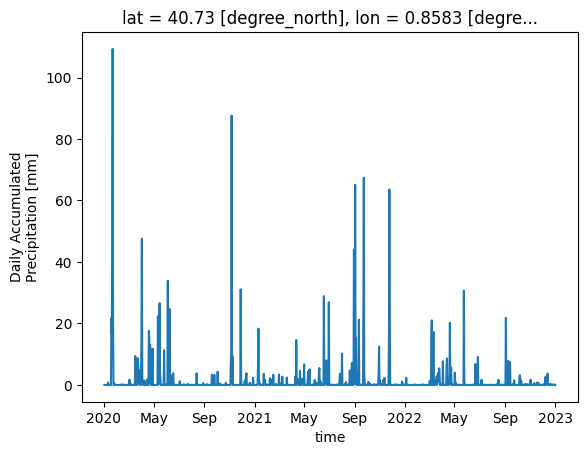

In [35]:
%%time 
ds['pr'].sel(lon=0.858, lat=40.725, method='nearest').plot();

CPU times: user 4.47 s, sys: 3.82 s, total: 8.29 s
Wall time: 4.22 s


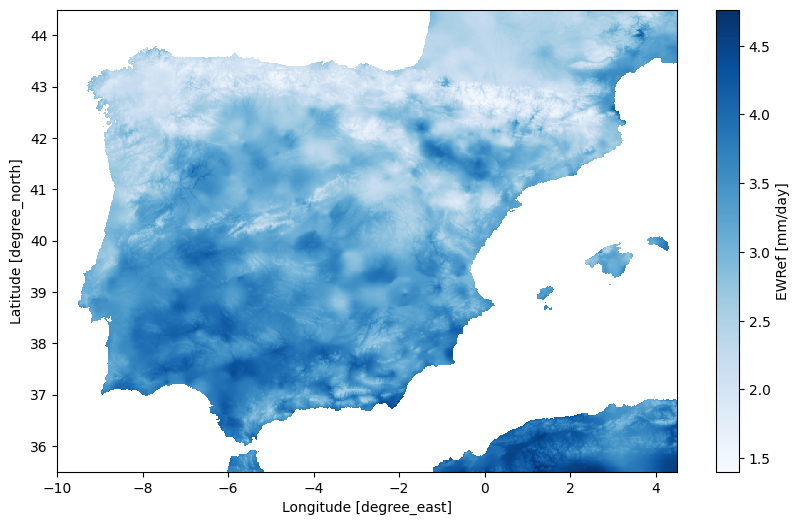

In [40]:
%%time
ds['e0'].mean('time').plot(figsize=(10, 6), cmap='Blues');

## Plot

In [ ]:
import hvplot.xarray
# This creates an interactive slider for 'time'
ds.dis.hvplot.image(x='lon', y='lat', rasterize=True, cmap='viridis')